# 20 — XGBoost v4.2: Structural + Spatial + NLP + Gemini Image Features
## RentSignal — The Full Feature Stack

**Goal:** Retrain with all available features including Gemini multimodal image analysis.

| Feature Group | Count | Source |
|---------------|-------|--------|
| Structural (numeric + binary) | 16 | Listing data |
| NLP title features | 9 | Title keyword extraction |
| Quick features | 3 | picturecount, nebenkosten, heatingGroup |
| Categorical | 7 | condition, style, bezirk, etc. |
| Spatial (unit-level) | 24 | OSM + Sentinel-2 |
| Gemini image (numeric) | 6 | interior, kitchen, bathroom, brightness, renovation, bldg_condition |
| Gemini image (bool) | 6 | is_render, is_furnished, visible_kitchen, visible_balcony, bldg_green, bldg_commercial |
| Gemini image (categorical) | 4 | style_img, floor_type_img, ceiling_height_img, bldg_style_img |
| **Total** | **~75** | |

In [2]:
import sys, json, hashlib, re, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import joblib
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
MODEL_DIR = PROJECT_ROOT / 'models'

# Load all 4 tables
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
spatial = pd.read_parquet(PROC_DIR / 'spatial_unit.parquet')
gemini = pd.read_parquet(PROC_DIR / 'gemini_image_features.parquet')

print(f'Units:    {len(units):,}')
print(f'Listings: {len(listings):,}')
print(f'Spatial:  {len(spatial):,}')
print(f'Gemini:   {len(gemini):,}')

# Merge all by unit_id
df = units.merge(listings[['unit_id', 'rent_sqm', 'baseRent', 'totalRent', 'serviceCharge']], on='unit_id')
df = df.merge(spatial.drop(columns=['coord_source']), on='unit_id', how='left')
df = df.merge(gemini, on='unit_id', how='left', suffixes=('', '_img'))

# Flag which units have image features
df['has_gemini'] = df['interior_quality'].notna()
print(f'\nMerged: {len(df):,} rows')
print(f'With Gemini features: {df["has_gemini"].sum():,} ({100*df["has_gemini"].mean():.1f}%)')
print(f'Without: {(~df["has_gemini"]).sum():,}')

Units:    8,256
Listings: 8,256
Spatial:  8,250
Gemini:   6,997

Merged: 8,256 rows
With Gemini features: 6,997 (84.8%)
Without: 1,259


## 1. Feature Engineering (all sources combined)

In [3]:
# Load raw JSON for NLP title features (same as notebook 18)
RAW_FILE = RAW_DIR / 'scraping' / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)
raw_lookup = {str(r.get('adTargetingParameters', {}).get('obj_scoutId', '')): r for r in raw}

# --- NLP title features ---
def extract_title_features(scout_id):
    rec = raw_lookup.get(scout_id)
    if not rec:
        return {}
    title = rec.get('basicInfo', {}).get('title', '').lower()
    atp = rec.get('adTargetingParameters', {})
    return {
        'is_altbau': int('altbau' in title),
        'is_neubau': int('neubau' in title or 'erstbezug' in title),
        'is_furnished': int('möbliert' in title or 'furnished' in title or 'möbel' in title),
        'is_tauschwohnung': int('tausch' in title),
        'is_renovated': int('saniert' in title or 'renoviert' in title or 'modernisiert' in title),
        'is_wg': int('wg' in title or 'wohngemeinschaft' in title),
        'is_befristet': int('befristet' in title or 'zwischenmiete' in title),
        'has_terrasse': int('terrasse' in title or 'dachterrasse' in title),
        'is_dachgeschoss': int('dachgeschoss' in title or 'dg' in title),
        'picturecount': int(atp.get('obj_picturecount', 0) or 0),
    }

title_df = pd.DataFrame([extract_title_features(sid) for sid in df['scout_id']])
title_df.index = df.index
for col in title_df.columns:
    df[col] = title_df[col]

# --- Nebenkosten per m² ---
df['nebenkosten_sqm'] = df['serviceCharge'] / df['livingSpace'].replace(0, np.nan)

# --- HeatingGroup (collapse 49 → 8) ---
HEATING_GROUPS = {
    'gas': ['gas', 'natural_gas', 'liquid_gas'],
    'district': ['district_heating'],
    'oil': ['oil'],
    'electric': ['electric', 'electricity', 'night_storage_heater'],
    'heat_pump': ['heat_pump', 'geothermal', 'environmental_thermal_energy', 'solar_heating', 'air_water_heat_pump'],
    'central': ['central_heating', 'self_contained_central_heating'],
    'floor': ['floor_heating', 'underfloor_heating'],
    'combined': ['combined_heat_and_power_fossil_fuels', 'combined_heat_and_power_plant',
                 'combined_heat_and_power_regenerative_energy', 'combined_heat_and_power_renewable_energy'],
}
def group_heating(ht):
    ht_lower = str(ht).lower().strip()
    for group, keywords in HEATING_GROUPS.items():
        for kw in keywords:
            if kw in ht_lower:
                return group
    return 'unknown'
df['heatingGroup'] = df['heatingType'].apply(group_heating)

# --- Size category ---
def size_category(sqm):
    if sqm < 30: return 'micro'
    if sqm < 50: return 'small'
    if sqm < 70: return 'medium'
    if sqm < 100: return 'large'
    return 'xlarge'
df['sizeCategory'] = df['livingSpace'].apply(size_category)

# --- Better missing data (same as notebook 18) ---
from data.pipelines.ingestion import year_to_building_era

# yearConstructed from titles
def infer_year_from_title(scout_id):
    rec = raw_lookup.get(scout_id)
    if not rec: return None
    title = rec.get('basicInfo', {}).get('title', '').lower()
    if 'erstbezug' in title or 'neubau' in title: return 2024
    if 'altbau' in title: return 1905
    m = re.search(r'(19|20)\d{2}', title)
    if m:
        year = int(m.group())
        if 1850 <= year <= 2027: return year
    return None

mask = df['yearConstructed'].isna()
df.loc[mask, 'yearConstructed'] = df.loc[mask, 'scout_id'].apply(infer_year_from_title)

# thermalChar conditional medians
thermal_by_heat = df.groupby('heatingType')['thermalChar'].median()
for ht, med in thermal_by_heat.items():
    if pd.notna(med):
        m = (df['thermalChar'].isna()) & (df['heatingType'] == ht)
        df.loc[m, 'thermalChar'] = med

# floor from typeOfFlat
for flat_type, floor_val in {'ground_floor': 0, 'raised_ground_floor': 0, 'half_basement': -1, 'penthouse': 8}.items():
    m = (df['floor'].isna()) & (df['typeOfFlat'] == flat_type)
    df.loc[m, 'floor'] = floor_val

# Recalculate building_era
df['building_era'] = df['yearConstructed'].apply(year_to_building_era)

print('Feature engineering complete.')
print(f'Columns: {len(df.columns)}')

Feature engineering complete.
Columns: 97


## 2. Define Full Feature Set

In [4]:
# --- Full v4.2 feature set ---

NUMERIC_FEATURES = [
    'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors',
    'thermalChar', 'sqm_per_room', 'nebenkosten_sqm', 'picturecount',
]

BINARY_FEATURES = [
    'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst',
    'is_altbau', 'is_neubau', 'is_furnished', 'is_tauschwohnung',
    'is_renovated', 'is_wg', 'is_befristet', 'has_terrasse', 'is_dachgeschoss',
]

CATEGORICAL_FEATURES = [
    'condition', 'interiorQual', 'typeOfFlat', 'heatingGroup',
    'building_era', 'bezirk', 'sizeCategory',
]

SPATIAL_FEATURES = [
    'dist_cbd_m', 'dist_transit_m', 'dist_ubahn_m',
    'dist_park_m', 'dist_water_m', 'dist_school_m',
    'count_food_500m', 'count_food_1000m',
    'count_restaurant_500m', 'count_restaurant_1000m',
    'count_cafe_500m',
    'count_shop_500m', 'count_shop_1000m',
    'count_transit_1000m',
    'count_building_200m',
    'ndvi_100m', 'ndvi_250m', 'ndvi_500m',
    'ndwi_100m', 'ndwi_250m', 'ndwi_500m',
    'ndbi_100m', 'ndbi_250m', 'ndbi_500m',
]

GEMINI_NUMERIC = [
    'interior_quality', 'kitchen_quality', 'bathroom_quality',
    'brightness', 'renovation_level', 'bldg_condition',
    'bldg_floors', 'rooms_shown',
]

GEMINI_BINARY = [
    'is_render', 'has_visible_kitchen', 'has_visible_balcony',
    'bldg_green', 'bldg_commercial_gf',
    # Note: is_furnished from Gemini overlaps with NLP is_furnished — skip to avoid confusion
]

GEMINI_CATEGORICAL = [
    'style',        # altbau/modern/neubau/... from image (renamed to avoid clash)
    'floor_type',   # dielen/parkett/laminate/...
    'ceiling_height',  # high/normal/low
    'bldg_style',   # altbau/plattenbau/neubau/...
    'staging',      # empty/staged/lived_in/...
    'view_type',    # park/water/street/...
    'color_warmth', # warm/neutral/cool/dark
]

# Rename Gemini 'style' to 'style_img' to avoid clash with structural data
if 'style' in df.columns and 'style_img' not in df.columns:
    # Check if there's already a _img suffix from the merge
    pass  # The merge already created style_img if there was a clash

# Filter to only features that exist in df
all_feature_names = (NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES + 
                     SPATIAL_FEATURES + GEMINI_NUMERIC + GEMINI_BINARY + GEMINI_CATEGORICAL)
available = [f for f in all_feature_names if f in df.columns]
missing = [f for f in all_feature_names if f not in df.columns]

print(f'=== v4.2 Feature Set ===')
print(f'  Structural numeric:    {len([f for f in NUMERIC_FEATURES if f in df.columns])}')
print(f'  Structural binary:     {len([f for f in BINARY_FEATURES if f in df.columns])}')
print(f'  Categorical:           {len([f for f in CATEGORICAL_FEATURES if f in df.columns])}')
print(f'  Spatial:               {len([f for f in SPATIAL_FEATURES if f in df.columns])}')
print(f'  Gemini numeric:        {len([f for f in GEMINI_NUMERIC if f in df.columns])}')
print(f'  Gemini binary:         {len([f for f in GEMINI_BINARY if f in df.columns])}')
print(f'  Gemini categorical:    {len([f for f in GEMINI_CATEGORICAL if f in df.columns])}')
print(f'  Total available:       {len(available)}')
if missing:
    print(f'  Missing:               {missing}')

=== v4.2 Feature Set ===
  Structural numeric:    9
  Structural binary:     15
  Categorical:           7
  Spatial:               24
  Gemini numeric:        8
  Gemini binary:         5
  Gemini categorical:    7
  Total available:       75


## 3. Prepare Feature Matrix

In [5]:
# Separate feature types for proper handling
ALL_NUMERIC = [f for f in NUMERIC_FEATURES + GEMINI_NUMERIC if f in df.columns]
ALL_BINARY = [f for f in BINARY_FEATURES + GEMINI_BINARY if f in df.columns]
ALL_CATEGORICAL = [f for f in CATEGORICAL_FEATURES + GEMINI_CATEGORICAL if f in df.columns]
ALL_SPATIAL = [f for f in SPATIAL_FEATURES if f in df.columns]

ALL_FEATURES = ALL_NUMERIC + ALL_BINARY + ALL_CATEGORICAL + ALL_SPATIAL
TARGET = 'rent_sqm'

# --- Numeric: fill missing with median ---
for col in ALL_NUMERIC:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        df[col] = df[col].fillna(df[col].median())

# --- Binary: fill NaN with 0, ensure int ---
for col in ALL_BINARY:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# --- Spatial: fill missing with 0 ---
for col in ALL_SPATIAL:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# --- Categorical: fill with 'unknown', encode ---
for col in ALL_CATEGORICAL:
    df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[ALL_CATEGORICAL] = encoder.fit_transform(df[ALL_CATEGORICAL])

# Build feature matrix
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print(f'Feature matrix: {X.shape}')
print(f'  Numeric:     {len(ALL_NUMERIC)}')
print(f'  Binary:      {len(ALL_BINARY)}')
print(f'  Categorical: {len(ALL_CATEGORICAL)}')
print(f'  Spatial:     {len(ALL_SPATIAL)}')
print(f'  Total:       {len(ALL_FEATURES)}')
print(f'Any NaN: {X.isna().any().any()}')

Feature matrix: (8256, 75)
  Numeric:     17
  Binary:      20
  Categorical: 14
  Spatial:     24
  Total:       75
Any NaN: False


## 4. Train v4.2 with Best Params from v4.1 + Early Stopping

In [6]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f'Train: {len(X_tr):,}, Validation: {len(X_val):,}, Test: {len(X_test):,}')

# Use best params from v4.1 tuning
best_params = {
    'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0,
    'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03,
    'colsample_bytree': 0.6,
}

model = xgb.XGBRegressor(
    **best_params,
    n_estimators=2000,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
)

model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best validation RMSE: {model.best_score:.4f}')

Train: 5,613, Validation: 991, Test: 1,652
[0]	validation_0-rmse:7.95790
[100]	validation_0-rmse:4.25769
[200]	validation_0-rmse:4.11169
[300]	validation_0-rmse:4.07986
[400]	validation_0-rmse:4.06977
[500]	validation_0-rmse:4.06696
[519]	validation_0-rmse:4.06330

Best iteration: 469
Best validation RMSE: 4.0622


## 5. Evaluate — Full Model Comparison

  FULL MODEL COMPARISON: v3 → v4.0 → v4.1 → v4.2
  Model                     Data         Features       R²     RMSE      MAE
  -----------------------------------------------------------------------
  v3.0 (Kaggle+PLZ)         2019               37   0.7491     2.59     1.70
  v4.0 (Apify+Unit)         2026               43   0.7083     4.21     3.07
  v4.1 (+NLP+tuning)        2026               55   0.7361     4.00     2.92
  v4.2 (+Gemini images)     2026               75   0.7613     3.81     2.74
  -----------------------------------------------------------------------
  v4.1 → v4.2:  ΔR² = +0.0252  ΔRMSE = -0.19
  v4.0 → v4.2:  ΔR² = +0.0530  (total improvement)


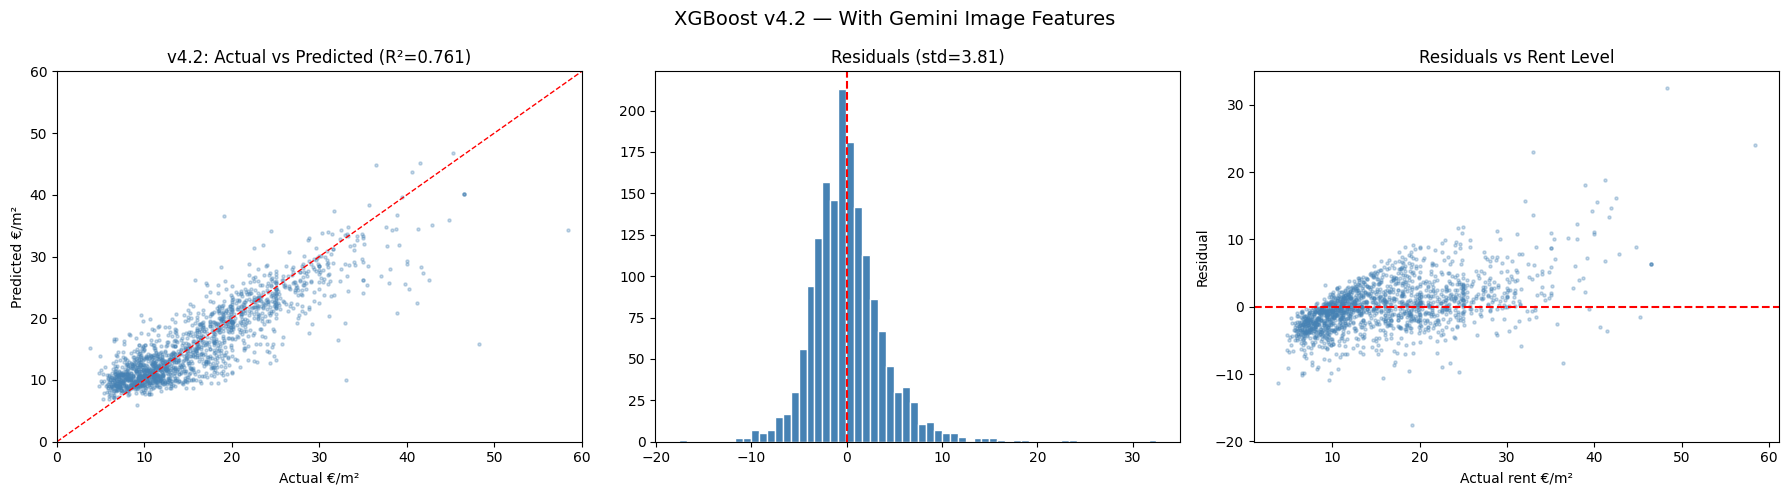

In [7]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('=' * 75)
print('  FULL MODEL COMPARISON: v3 → v4.0 → v4.1 → v4.2')
print('=' * 75)
print(f'  {"Model":<25} {"Data":<12} {"Features":>8} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print(f'  {"-"*71}')
print(f'  {"v3.0 (Kaggle+PLZ)":<25} {"2019":<12} {"37":>8} {"0.7491":>8} {"2.59":>8} {"1.70":>8}')
print(f'  {"v4.0 (Apify+Unit)":<25} {"2026":<12} {"43":>8} {"0.7083":>8} {"4.21":>8} {"3.07":>8}')
print(f'  {"v4.1 (+NLP+tuning)":<25} {"2026":<12} {"55":>8} {"0.7361":>8} {"4.00":>8} {"2.92":>8}')
print(f'  {"v4.2 (+Gemini images)":<25} {"2026":<12} {len(ALL_FEATURES):>8} {r2:>8.4f} {rmse:>8.2f} {mae:>8.2f}')
print(f'  {"-"*71}')
print(f'  v4.1 → v4.2:  ΔR² = {r2 - 0.7361:+.4f}  ΔRMSE = {rmse - 4.00:+.2f}')
print(f'  v4.0 → v4.2:  ΔR² = {r2 - 0.7083:+.4f}  (total improvement)')

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, s=5, alpha=0.3, c='steelblue')
ax.plot([0, 60], [0, 60], 'r--', linewidth=1)
ax.set_xlabel('Actual €/m²')
ax.set_ylabel('Predicted €/m²')
ax.set_title(f'v4.2: Actual vs Predicted (R²={r2:.3f})')
ax.set_xlim(0, 60)
ax.set_ylim(0, 60)

ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_title(f'Residuals (std={residuals.std():.2f})')

ax = axes[2]
ax.scatter(y_test, residuals, s=5, alpha=0.3, c='steelblue')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Actual rent €/m²')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Rent Level')

plt.suptitle('XGBoost v4.2 — With Gemini Image Features', fontsize=14)
plt.tight_layout()
plt.show()

## 6. SHAP — Full Feature Importance with Image Features

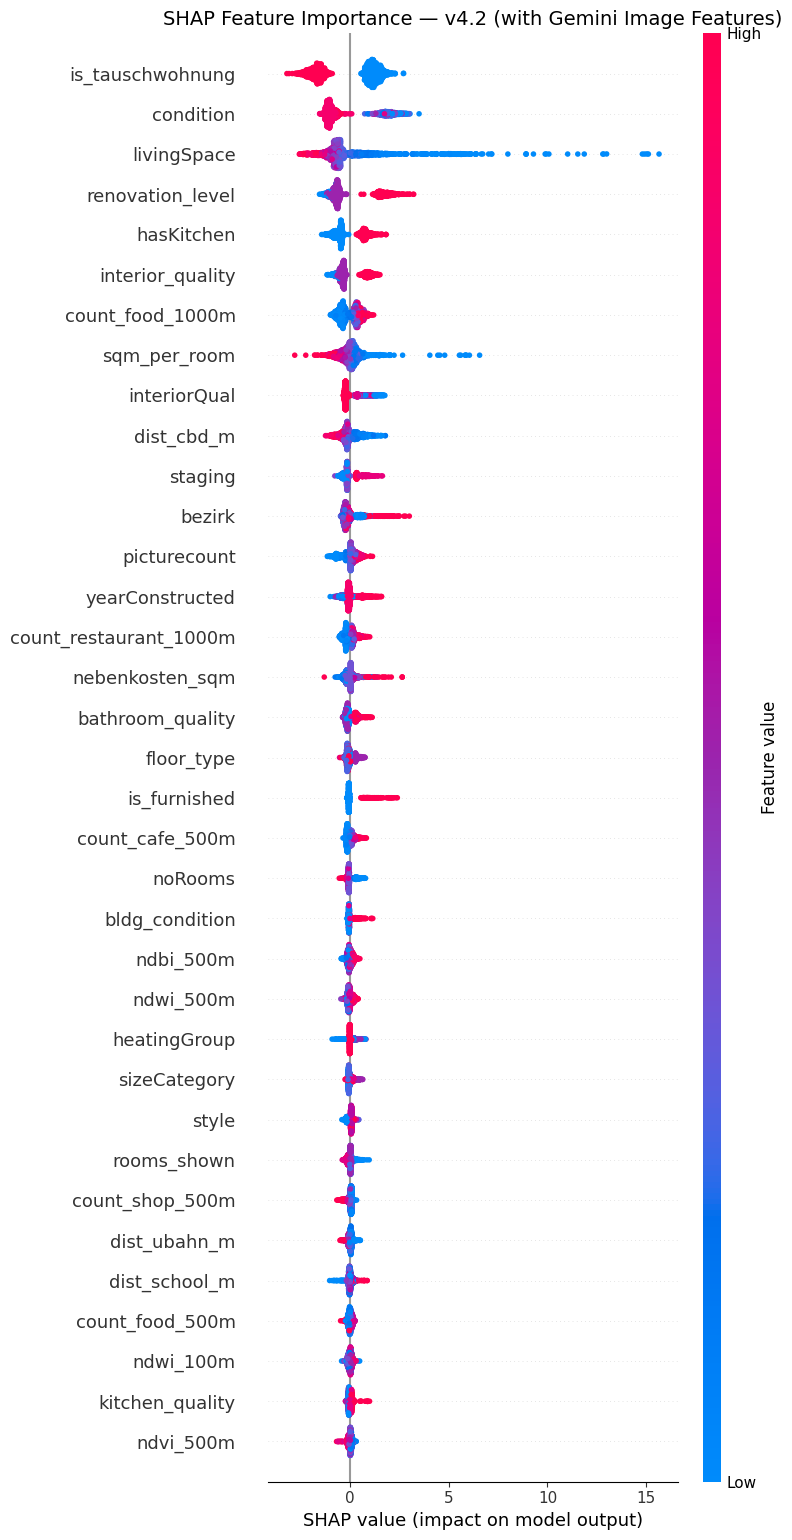

=== Top 30 Features by Mean |SHAP| ===
   1. is_tauschwohnung             1.431  [NLP]
   2. condition                    1.257  [STRUCT]
   3. livingSpace                  1.227  [STRUCT]
   4. renovation_level             1.064  [IMAGE]
   5. hasKitchen                   0.691  [STRUCT]
   6. interior_quality             0.583  [IMAGE]
   7. count_food_1000m             0.423  [SPATIAL]
   8. sqm_per_room                 0.384  [STRUCT]
   9. interiorQual                 0.363  [STRUCT]
  10. dist_cbd_m                   0.353  [SPATIAL]
  11. staging                      0.326  [IMAGE]
  12. bezirk                       0.312  [STRUCT]
  13. picturecount                 0.277  [NLP]
  14. yearConstructed              0.248  [STRUCT]
  15. count_restaurant_1000m       0.218  [SPATIAL]
  16. nebenkosten_sqm              0.198  [NLP]
  17. bathroom_quality             0.194  [IMAGE]
  18. floor_type                   0.158  [IMAGE]
  19. is_furnished                 0.143  [NLP]
  20. 

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 16))
shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES, show=False, max_display=35)
plt.title('SHAP Feature Importance — v4.2 (with Gemini Image Features)', fontsize=14)
plt.tight_layout()
plt.show()

# Ranked table
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': ALL_FEATURES, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)

print('=== Top 30 Features by Mean |SHAP| ===')
for i, (_, row) in enumerate(shap_df.head(30).iterrows()):
    f = row['feature']
    if f in GEMINI_NUMERIC + GEMINI_BINARY + GEMINI_CATEGORICAL:
        tag = 'IMAGE'
    elif f in SPATIAL_FEATURES:
        tag = 'SPATIAL'
    elif f.startswith('is_') or f in ['picturecount', 'nebenkosten_sqm', 'has_terrasse']:
        tag = 'NLP'
    else:
        tag = 'STRUCT'
    print(f'  {i+1:>2}. {f:<28} {row["mean_abs_shap"]:.3f}  [{tag}]')

# Count by group in top 20
top20 = shap_df.head(20)['feature'].tolist()
n_image = sum(1 for f in top20 if f in GEMINI_NUMERIC + GEMINI_BINARY + GEMINI_CATEGORICAL)
n_spatial = sum(1 for f in top20 if f in SPATIAL_FEATURES)
n_nlp = sum(1 for f in top20 if f.startswith('is_') or f in ['picturecount', 'nebenkosten_sqm', 'has_terrasse'])
n_struct = 20 - n_image - n_spatial - n_nlp
print(f'\nTop 20 composition: {n_struct} structural, {n_image} image, {n_spatial} spatial, {n_nlp} NLP')

## 7. Save v4.2 Artifacts

In [9]:
# Save only if improved over v4.1
if r2 > 0.7361:
    joblib.dump(model, MODEL_DIR / 'xgboost_rent_v4.joblib')
    joblib.dump(explainer, MODEL_DIR / 'shap_explainer_v4.joblib')
    joblib.dump(encoder, MODEL_DIR / 'feature_encoder_v4.joblib')
    
    config = {
        'model_version': 'v4.2.0',
        'trained_at': datetime.now().isoformat(),
        'data_source': 'apify_immoscout24_berlin_2026_03',
        'data_files': {
            'units': 'data/processed/units.parquet',
            'listings': 'data/processed/listings.parquet',
            'spatial_unit': 'data/processed/spatial_unit.parquet',
            'gemini_image_features': 'data/processed/gemini_image_features.parquet',
        },
        'inflation_factor': 1.0,
        'inflation_factor_active': False,
        'features': ALL_FEATURES,
        'feature_groups': {
            'numeric': ALL_NUMERIC,
            'binary': ALL_BINARY,
            'categorical': ALL_CATEGORICAL,
            'spatial': ALL_SPATIAL,
            'gemini_numeric': [f for f in GEMINI_NUMERIC if f in df.columns],
            'gemini_binary': [f for f in GEMINI_BINARY if f in df.columns],
            'gemini_categorical': [f for f in GEMINI_CATEGORICAL if f in df.columns],
        },
        'spatial_level': 'unit',
        'image_features': True,
        'image_model': 'gemini-2.5-flash',
        'image_coverage': f'{len(gemini)}/{len(units)} ({100*len(gemini)/len(units):.0f}%)',
        'best_params': {**best_params, 'n_estimators': model.best_iteration},
        'train_size': len(X_train),
        'test_size': len(X_test),
        'metrics': {'r2': round(r2, 4), 'rmse': round(rmse, 4), 'mae': round(mae, 4)},
        'version_history': {
            'v3.0': {'r2': 0.7491, 'rmse': 2.59, 'features': 37, 'data': 'Kaggle 2019 + PLZ spatial'},
            'v4.0': {'r2': 0.7083, 'rmse': 4.21, 'features': 43, 'data': '2026 Apify + unit spatial'},
            'v4.1': {'r2': 0.7361, 'rmse': 4.00, 'features': 55, 'data': '+ NLP title + tuning'},
            'v4.2': {'r2': round(r2, 4), 'rmse': round(rmse, 4), 'features': len(ALL_FEATURES), 'data': '+ Gemini image features'},
        },
        'artifacts': {
            'model': 'models/xgboost_rent_v4.joblib',
            'shap_explainer': 'models/shap_explainer_v4.joblib',
            'feature_encoder': 'models/feature_encoder_v4.joblib',
        },
    }
    
    with open(MODEL_DIR / 'model_config.json', 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f'=== v4.2 SAVED ===')
    print(f'  R²:       {r2:.4f} (v4.1 was 0.7361, v3 was 0.7491)')
    print(f'  RMSE:     {rmse:.2f} €/m²')
    print(f'  Features: {len(ALL_FEATURES)}')
    print(f'  Image features added: {len(GEMINI_NUMERIC) + len(GEMINI_BINARY) + len(GEMINI_CATEGORICAL)}')
else:
    print(f'  v4.2 R² ({r2:.4f}) did not improve over v4.1 (0.7361)')
    print(f'  Model NOT saved. Consider: feature selection, different image features, or more data.')

=== v4.2 SAVED ===
  R²:       0.7613 (v4.1 was 0.7361, v3 was 0.7491)
  RMSE:     3.81 €/m²
  Features: 75
  Image features added: 20
